# MEOW金融时序预测实验 - 数据分析阶段

## 实验概述
本项目是西北工业大学《模式识别与机器学习》课程的金融时序预测实验。
目标：预测股票未来12分钟收益率（fret12）。
数据：300只股票的分钟级交易数据（2023年6月-12月）。

## 第一步：数据加载与基本统计分析

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 设置中文显示和图表样式
##plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号
sns.set_style("whitegrid")

# 数据路径
DATA_DIR = Path("../archive")  # H5文件存放目录
OUTPUT_DIR = Path("./output")  # 输出目录

# 创建输出目录
OUTPUT_DIR.mkdir(exist_ok=True)

print("实验环境设置完成")
print(f"数据目录: {DATA_DIR.absolute()}")
print(f"输出目录: {OUTPUT_DIR.absolute()}")

实验环境设置完成
数据目录: c:\Users\fengjian\Desktop\模式识别与机器学习作业\work\ceshi\..\archive
输出目录: c:\Users\fengjian\Desktop\模式识别与机器学习作业\work\ceshi\output


## 1.1 查看数据文件

In [2]:
# 查看数据文件列表
h5_files = sorted(list(DATA_DIR.glob("*.h5")))
print(f"共找到 {len(h5_files)} 个H5文件")
print("\n前20个文件:")
for i, file in enumerate(h5_files[:20]):
    print(f"  {i:3d}. {file.name}")
if len(h5_files) > 20:
    print(f"  ... 还有 {len(h5_files)-20} 个文件")

# 查看文件大小
file_sizes = [(file.name, file.stat().st_size / (1024*1024)) for file in h5_files]
df_sizes = pd.DataFrame(file_sizes, columns=["文件名", "大小(MB)"])
print("\n文件大小统计:")
print(df_sizes.describe())

共找到 144 个H5文件

前20个文件:
    0. 20230601.h5
    1. 20230602.h5
    2. 20230605.h5
    3. 20230606.h5
    4. 20230607.h5
    5. 20230608.h5
    6. 20230609.h5
    7. 20230612.h5
    8. 20230613.h5
    9. 20230614.h5
   10. 20230615.h5
   11. 20230616.h5
   12. 20230619.h5
   13. 20230620.h5
   14. 20230621.h5
   15. 20230626.h5
   16. 20230627.h5
   17. 20230628.h5
   18. 20230629.h5
   19. 20230630.h5
  ... 还有 124 个文件

文件大小统计:
           大小(MB)
count  144.000000
mean    16.217813
std      0.242254
min     15.680964
25%     16.048517
50%     16.191687
75%     16.391328
max     16.873107


## 1.2 加载单个文件进行初步探索

In [3]:
# 加载第一个文件（20230601）
sample_file = h5_files[0]
print(f"加载文件: {sample_file.name}")

# 读取H5文件
df = pd.read_hdf(sample_file)

# 查看基本信息
print(f"数据形状: {df.shape}")
print(f"列数: {df.shape[1]}")
print(f"行数: {df.shape[0]:,}")
print(f"内存使用: {df.memory_usage(deep=True).sum() / (1024*1024):.2f} MB")

# 查看列名
print("\n所有列名:")
print(", ".join(df.columns.tolist()))

# 查看数据类型
print("\n数据类型统计:")
print(df.dtypes.value_counts())

加载文件: 20230601.h5
数据形状: (69347, 62)
列数: 62
行数: 69,347
内存使用: 33.33 MB

所有列名:
symbol, interval, fret12, midpx, lastpx, open, high, low, bid0, ask0, bid4, ask4, bid9, ask9, bid19, ask19, bsize0, asize0, bsize0_4, asize0_4, bsize5_9, asize5_9, bsize10_19, asize10_19, btr0_4, atr0_4, btr5_9, atr5_9, btr10_19, atr10_19, nTradeBuy, tradeBuyQty, tradeBuyTurnover, tradeBuyHigh, tradeBuyLow, buyVwad, nTradeSell, tradeSellQty, tradeSellTurnover, tradeSellHigh, tradeSellLow, sellVwad, nAddBuy, addBuyQty, addBuyTurnover, addBuyHigh, addBuyLow, nAddSell, addSellQty, addSellTurnover, addSellHigh, addSellLow, nCxlBuy, cxlBuyQty, cxlBuyTurnover, cxlBuyHigh, cxlBuyLow, nCxlSell, cxlSellQty, cxlSellTurnover, cxlSellHigh, cxlSellLow

数据类型统计:
float64    60
int64       2
Name: count, dtype: int64


## 1.3 查看前几行数据

In [4]:
# 显示前5行数据
print("前5行数据:")
print(df.head())

# 显示后5行数据
print("\n后5行数据:")
print(df.tail())

前5行数据:
     symbol  interval    fret12   midpx  lastpx   open   high    low   bid0  \
0  90000063  93000000  0.010716  34.995     NaN    NaN    NaN    NaN  34.99   
1  90000063  93100000  0.008109  35.145   35.15  35.00  35.18  34.90  35.14   
2  90000063  93200000  0.003972  35.245   35.26  35.14  35.30  35.08  35.23   
3  90000063  93300000  0.004252  35.280   35.30  35.24  35.39  35.21  35.27   
4  90000063  93400000  0.004682  35.240   35.23  35.29  35.35  35.19  35.23   

    ask0  ...  nCxlBuy  cxlBuyQty  cxlBuyTurnover  cxlBuyHigh  cxlBuyLow  \
0  35.00  ...      0.0        0.0            0.00         NaN        NaN   
1  35.15  ...    204.0   293963.0     10243005.89       35.17      31.66   
2  35.26  ...    283.0   597740.0     21001447.20       35.26      31.66   
3  35.29  ...    203.0   387100.0     13620642.00       35.33      33.00   
4  35.25  ...    157.0    89400.0      3139528.00       35.32      31.67   

   nCxlSell  cxlSellQty  cxlSellTurnover  cxlSellHigh  cxlSel

## 1.4 检查目标变量分布

In [5]:
# 检查目标变量fret12
if 'fret12' in df.columns:
    print("目标变量fret12统计信息:")
    print(df['fret12'].describe())
    
    # 基本统计
    print(f"\n目标变量fret12详细统计:")
    print(f"  均值: {df['fret12'].mean():.6f}")
    print(f"  标准差: {df['fret12'].std():.6f}")
    print(f"  最小值: {df['fret12'].min():.6f}")
    print(f"  最大值: {df['fret12'].max():.6f}")
    print(f"  25%分位数: {df['fret12'].quantile(0.25):.6f}")
    print(f"  中位数: {df['fret12'].median():.6f}")
    print(f"  75%分位数: {df['fret12'].quantile(0.75):.6f}")
    
    # 分布比例
    total = len(df['fret12'])
    positive = (df['fret12'] > 0).sum()
    negative = (df['fret12'] < 0).sum()
    zero = (df['fret12'] == 0).sum()
    
    print(f"\n收益率分布:")
    print(f"  正收益率: {positive:,} ({positive/total*100:.2f}%)")
    print(f"  负收益率: {negative:,} ({negative/total*100:.2f}%)")
    print(f"  零收益率: {zero:,} ({zero/total*100:.2f}%)")
else:
    print("警告: 未找到fret12列")

目标变量fret12统计信息:
count    69347.000000
mean         0.000640
std          0.007240
min         -0.058534
25%         -0.002623
50%          0.000000
75%          0.002871
max          0.090754
Name: fret12, dtype: float64

目标变量fret12详细统计:
  均值: 0.000640
  标准差: 0.007240
  最小值: -0.058534
  最大值: 0.090754
  25%分位数: -0.002623
  中位数: 0.000000
  75%分位数: 0.002871

收益率分布:
  正收益率: 32,079 (46.26%)
  负收益率: 33,537 (48.36%)
  零收益率: 3,731 (5.38%)


## 1.5 检查股票和时间分布

In [6]:
# 检查股票代码分布
if 'symbol' in df.columns:
    print(f"股票数量: {df['symbol'].nunique()}")
    print(f"股票代码示例: {sorted(df['symbol'].unique())[:10]}")
    
    # 股票数量分布
    symbol_counts = df['symbol'].value_counts()
    print(f"\n每只股票的平均数据条数: {symbol_counts.mean():.1f}")
    print(f"数据最多股票的条数: {symbol_counts.max():,}")
    print(f"数据最少股票的条数: {symbol_counts.min():,}")

# 检查时间分布
if 'interval' in df.columns:
    print(f"\n时间间隔数量: {df['interval'].nunique()}")
    print(f"时间范围: {df['interval'].min()} - {df['interval'].max()}")
    
    # 转换为可读时间
    intervals = df['interval'].unique()
    sorted_intervals = sorted(intervals)
    
    # 检查时间间隔
    diffs = np.diff(sorted_intervals)
    if len(diffs) > 0:
        print(f"时间间隔统计:")
        print(f"  平均间隔: {diffs.mean():,.0f} 毫秒")
        print(f"  最小间隔: {diffs.min():,.0f} 毫秒")
        print(f"  最大间隔: {diffs.max():,.0f} 毫秒")
        print(f"  标准差: {diffs.std():,.0f} 毫秒")
        
        # 检查是否是固定间隔
        if np.all(diffs == diffs[0]):
            print(f"  时间间隔是固定的: {diffs[0]:,.0f} 毫秒")
        else:
            print(f"  时间间隔不是固定的")
            
    # 显示前几个时间点
    print(f"\n前5个时间点:")
    for interval in sorted_intervals[:5]:
        total_ms = int(interval)
        hours = total_ms // 3600000
        minutes = (total_ms % 3600000) // 60000
        seconds = (total_ms % 60000) // 1000
        print(f"  {interval} -> {hours:02d}:{minutes:02d}:{seconds:02d}")

股票数量: 309
股票代码示例: [90000063, 90000151, 90000157, 90000338, 90000400, 90000423, 90000516, 90000539, 90000543, 90000581]

每只股票的平均数据条数: 224.4
数据最多股票的条数: 226
数据最少股票的条数: 1

时间间隔数量: 226
时间范围: 93000000 - 144500000
时间间隔统计:
  平均间隔: 228,889 毫秒
  最小间隔: 100,000 毫秒
  最大间隔: 17,100,000 毫秒
  标准差: 1,217,031 毫秒
  时间间隔不是固定的

前5个时间点:
  93000000 -> 25:50:00
  93100000 -> 25:51:40
  93200000 -> 25:53:20
  93300000 -> 25:55:00
  93400000 -> 25:56:40


## 1.6 查看缺失值情况

In [7]:
# 检查缺失值
print("缺失值统计:")
missing = df.isnull().sum()
missing_percentage = missing / len(df) * 100

# 创建缺失值统计DataFrame
missing_df = pd.DataFrame({
    '缺失数量': missing,
    '缺失比例(%)': missing_percentage
})

# 只显示有缺失值的列
missing_df = missing_df[missing_df['缺失数量'] > 0].sort_values('缺失数量', ascending=False)

print(f"有缺失值的列数: {len(missing_df)}")
print(f"总列数: {len(df.columns)}")

if len(missing_df) > 0:
    print("\n缺失值详情:")
    print(missing_df.head(20))  # 显示前20个有缺失的列
    
    # 统计缺失值严重的列
    high_missing = missing_df[missing_df['缺失比例(%)'] > 5]
    if len(high_missing) > 0:
        print(f"\n缺失比例大于5%的列数: {len(high_missing)}")
        print(high_missing)
else:
    print("\n没有缺失值")

缺失值统计:
有缺失值的列数: 22
总列数: 62

缺失值详情:
               缺失数量   缺失比例(%)
cxlSellLow     1506  2.171687
cxlSellHigh    1506  2.171687
cxlBuyLow      1295  1.867420
cxlBuyHigh     1295  1.867420
sellVwad       1242  1.790993
tradeBuyLow    1206  1.739080
tradeBuyHigh   1206  1.739080
buyVwad        1050  1.514125
tradeSellLow   1016  1.465096
tradeSellHigh  1016  1.465096
open            448  0.646027
low             448  0.646027
high            448  0.646027
lastpx          448  0.646027
addSellHigh     357  0.514802
addSellLow      357  0.514802
addBuyHigh      352  0.507592
addBuyLow       352  0.507592
bid19           139  0.200441
ask19             2  0.002884


## 1.7 数据可视化探索

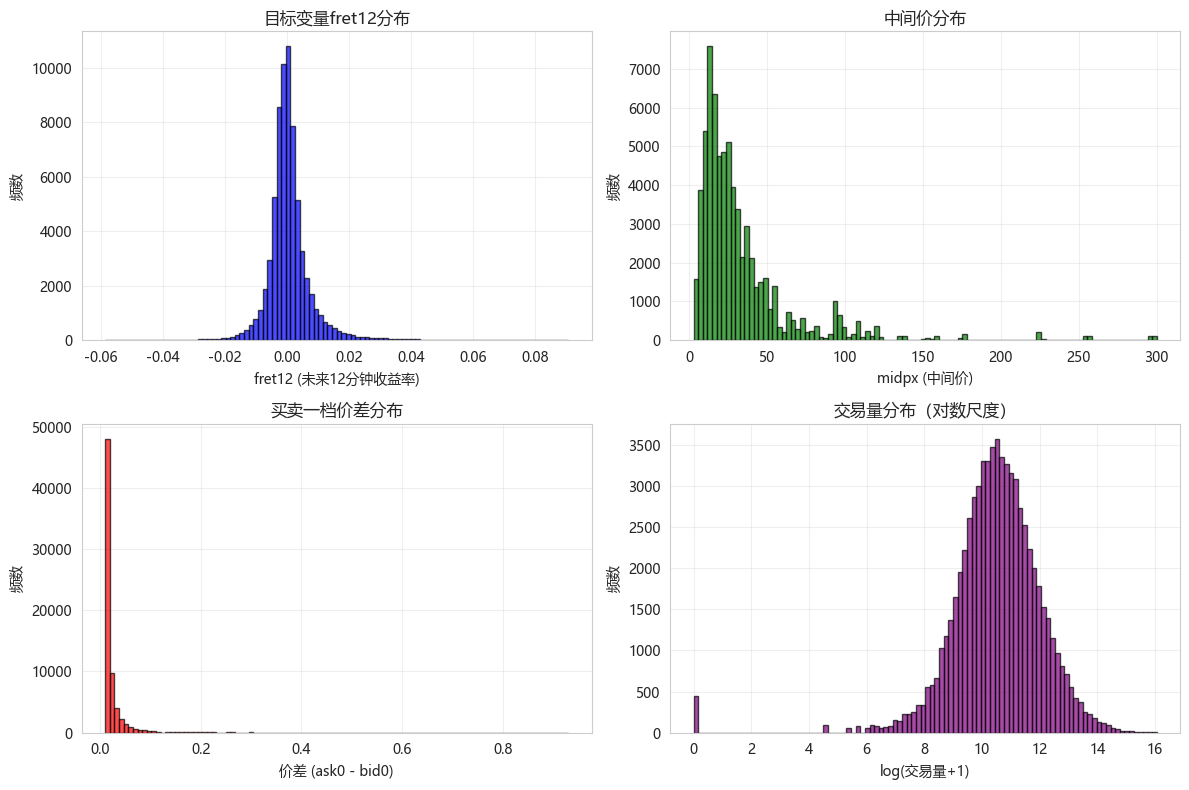

In [13]:
# 绘制目标变量分布图
plt.figure(figsize=(12, 8))
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
# 1. 目标变量分布直方图
plt.subplot(2, 2, 1)
plt.hist(df['fret12'].dropna(), bins=100, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('fret12 (未来12分钟收益率)')
plt.ylabel('频数')
plt.title('目标变量fret12分布')
plt.grid(True, alpha=0.3)

# 2. 中间价分布
plt.subplot(2, 2, 2)
plt.hist(df['midpx'].dropna(), bins=100, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('midpx (中间价)')
plt.ylabel('频数')
plt.title('中间价分布')
plt.grid(True, alpha=0.3)

# 3. 买卖一档价差分布
plt.subplot(2, 2, 3)
spread = df['ask0'] - df['bid0']
plt.hist(spread.dropna(), bins=100, alpha=0.7, color='red', edgecolor='black')
plt.xlabel('价差 (ask0 - bid0)')
plt.ylabel('频数')
plt.title('买卖一档价差分布')
plt.grid(True, alpha=0.3)

# 4. 交易量分布（对数尺度）
plt.subplot(2, 2, 4)
trade_qty = df['tradeBuyQty'] + df['tradeSellQty']
plt.hist(np.log1p(trade_qty).dropna(), bins=100, alpha=0.7, color='purple', edgecolor='black')
plt.xlabel('log(交易量+1)')
plt.ylabel('频数')
plt.title('交易量分布（对数尺度）')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'basic_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.8 相关性分析

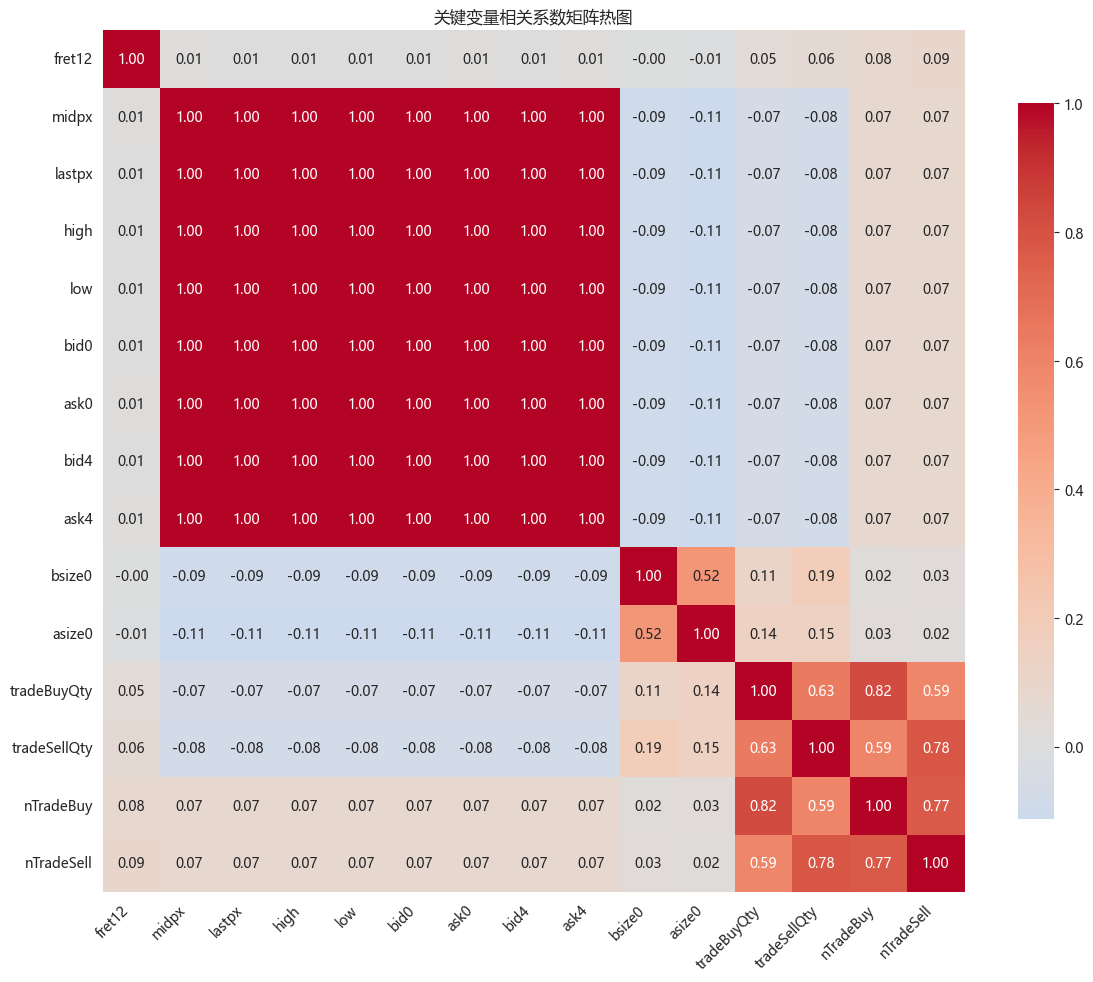

与fret12相关性最高的前20个变量:
   1. fret12         : 1.0000
   2. nTradeSell     : 0.0903
   3. nTradeBuy      : 0.0764
   4. tradeSellQty   : 0.0604
   5. tradeBuyQty    : 0.0464
   6. asize0         : -0.0123
   7. ask4           : 0.0088
   8. ask0           : 0.0087
   9. midpx          : 0.0087
  10. bid0           : 0.0087
  11. bid4           : 0.0087
  12. high           : 0.0079
  13. lastpx         : 0.0077
  14. low            : 0.0075
  15. bsize0         : -0.0035


In [15]:
# 选择部分关键列进行相关性分析
key_columns = [
    'fret12',  # 目标变量
    'midpx', 'lastpx', 'high', 'low',  # 价格
    'bid0', 'ask0', 'bid4', 'ask4',  # 买卖价格
    'bsize0', 'asize0',  # 买卖数量
    'tradeBuyQty', 'tradeSellQty',  # 交易量
    'nTradeBuy', 'nTradeSell',  # 交易次数
]

# 只保留数据中存在的列
existing_columns = [col for col in key_columns if col in df.columns]

if len(existing_columns) > 0:
    # 计算相关系数矩阵
    corr_matrix = df[existing_columns].corr()
    
    # 绘制热图
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, 
                annot=True, 
                fmt=".2f", 
                cmap='coolwarm',
                center=0,
                square=True,
                cbar_kws={"shrink": .8})
    plt.title('关键变量相关系数矩阵热图')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 查看与fret12相关性最高的变量
    if 'fret12' in corr_matrix.columns:
        print("与fret12相关性最高的前20个变量:")
        fret12_corr = corr_matrix['fret12'].abs().sort_values(ascending=False)
        for i, (var, corr) in enumerate(fret12_corr.head(20).items()):
            actual_corr = corr_matrix.loc['fret12', var]
            print(f"  {i+1:2d}. {var:<15}: {actual_corr:.4f}")
else:
    print("警告: 未找到关键变量列")

## 1.9 时间序列模式分析

选择股票代码: 90000063 进行分析


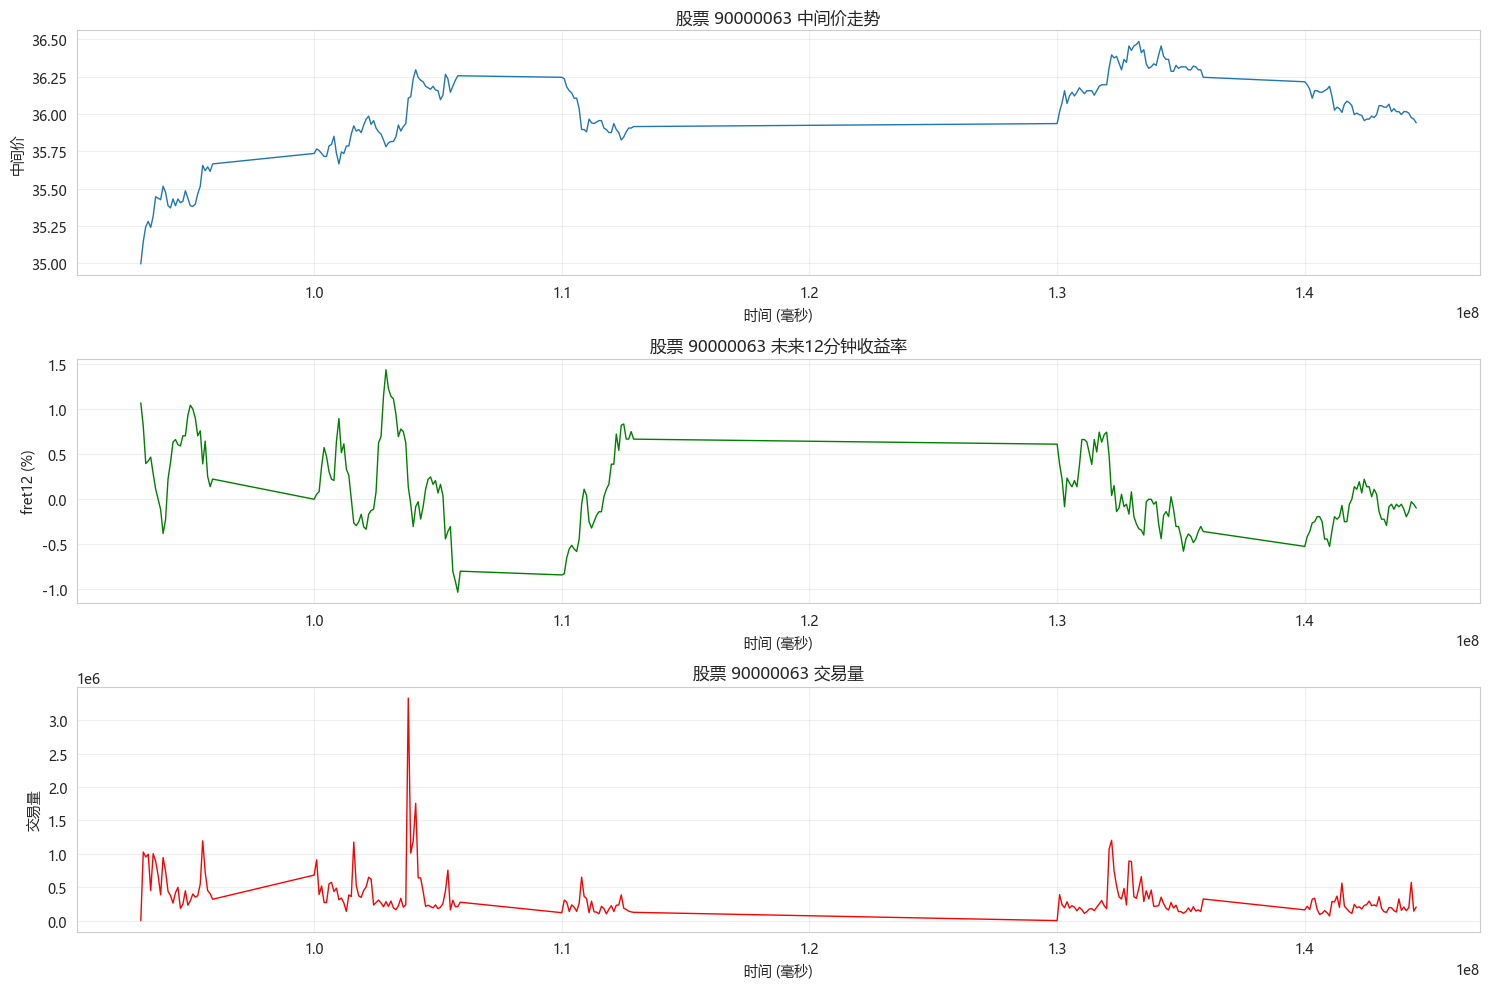


股票 90000063 统计信息:
  数据点数: 226
  时间范围: 25:50:00 - 40:08:20
  价格范围: 35.00 - 36.48
  fret12范围: -1.03% - 1.44%


In [16]:
# 选择一个股票进行分析
if 'symbol' in df.columns:
    sample_symbol = df['symbol'].iloc[0]
    print(f"选择股票代码: {sample_symbol} 进行分析")
    
    # 提取该股票数据
    stock_df = df[df['symbol'] == sample_symbol].copy()
    stock_df = stock_df.sort_values('interval')
    
    # 转换时间为可读格式
    stock_df['time_str'] = stock_df['interval'].apply(lambda x: f"{x//3600000:02d}:{(x%3600000)//60000:02d}:{(x%60000)//1000:02d}")
    
    # 绘制价格序列
    plt.figure(figsize=(15, 10))
    
    # 1. 中间价走势
    plt.subplot(3, 1, 1)
    plt.plot(stock_df['interval'], stock_df['midpx'], linewidth=1)
    plt.xlabel('时间 (毫秒)')
    plt.ylabel('中间价')
    plt.title(f'股票 {sample_symbol} 中间价走势')
    plt.grid(True, alpha=0.3)
    
    # 2. 目标变量fret12
    plt.subplot(3, 1, 2)
    plt.plot(stock_df['interval'], stock_df['fret12'] * 100, linewidth=1, color='green')
    plt.xlabel('时间 (毫秒)')
    plt.ylabel('fret12 (%)')
    plt.title(f'股票 {sample_symbol} 未来12分钟收益率')
    plt.grid(True, alpha=0.3)
    
    # 3. 交易量
    plt.subplot(3, 1, 3)
    plt.plot(stock_df['interval'], stock_df['tradeBuyQty'] + stock_df['tradeSellQty'], 
             linewidth=1, color='red')
    plt.xlabel('时间 (毫秒)')
    plt.ylabel('交易量')
    plt.title(f'股票 {sample_symbol} 交易量')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'time_series_sample.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 打印该股票的基本统计
    print(f"\n股票 {sample_symbol} 统计信息:")
    print(f"  数据点数: {len(stock_df)}")
    print(f"  时间范围: {stock_df['time_str'].iloc[0]} - {stock_df['time_str'].iloc[-1]}")
    print(f"  价格范围: {stock_df['midpx'].min():.2f} - {stock_df['midpx'].max():.2f}")
    print(f"  fret12范围: {stock_df['fret12'].min()*100:.2f}% - {stock_df['fret12'].max()*100:.2f}%")
    
else:
    print("警告: 数据中没有symbol列")

## 1.10 保存分析结果

In [17]:
# 创建数据摘要
data_summary = {
    '文件总数': len(h5_files),
    '样本文件': sample_file.name,
    '数据形状': df.shape,
    '总行数': df.shape[0],
    '总列数': df.shape[1],
    '内存使用(MB)': df.memory_usage(deep=True).sum() / (1024*1024),
    '股票数量': df['symbol'].nunique() if 'symbol' in df.columns else None,
    '时间点数量': df['interval'].nunique() if 'interval' in df.columns else None,
    '目标变量fret12均值': df['fret12'].mean() if 'fret12' in df.columns else None,
    '目标变量fret12标准差': df['fret12'].std() if 'fret12' in df.columns else None,
    '有缺失值的列数': df.isnull().any().sum(),
    '数据类型': dict(df.dtypes.value_counts())
}

# 保存摘要到文件
summary_df = pd.DataFrame(list(data_summary.items()), columns=['指标', '值'])
summary_df.to_csv(OUTPUT_DIR / 'data_summary.csv', index=False, encoding='utf-8-sig')

print("数据分析摘要:")
print("=" * 60)
for key, value in data_summary.items():
    print(f"{key:<20}: {value}")
print("=" * 60)
print(f"\n分析结果已保存到: {OUTPUT_DIR.absolute()}")

数据分析摘要:
文件总数                : 144
样本文件                : 20230601.h5
数据形状                : (69347, 62)
总行数                 : 69347
总列数                 : 62
内存使用(MB)            : 33.331764221191406
股票数量                : 309
时间点数量               : 226
目标变量fret12均值        : 0.0006398528723120407
目标变量fret12标准差       : 0.007240402786055399
有缺失值的列数             : 22
数据类型                : {dtype('float64'): 60, dtype('int64'): 2}

分析结果已保存到: c:\Users\fengjian\Desktop\模式识别与机器学习作业\work\ceshi\output


## 下一步建议

基于本次数据分析，可以得出的初步结论和下一步方向：

1. **数据质量**：检查缺失值情况，特别是fret12是否有缺失
2. **数据分布**：了解收益率分布特征，是否符合正态分布
3. **时间序列特性**：检查是否有季节性或周期性模式
4. **相关性分析**：找出与fret12相关性最高的变量
5. **异常值检测**：识别并处理异常值

在下一个notebook中，我们将进行：
1. 更多股票的统计分析
2. 跨日数据的合并分析  
3. 特征重要性的初步评估
4. 数据预处理方案设计